In [ ]:
!pip install keras_vggface
!pip install keras_applications

In [3]:
import os
import cv2
from scipy.stats import kurtosis, skew
import pandas as pd
from PIL import Image, ImageEnhance, ImageOps, ImageDraw, ImageFilter
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras import layers 
from tensorflow.keras import Model
from keras_vggface.vggface import VGGFace
from keras_vggface import utils
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
import numpy as np
from matplotlib.patches import Rectangle
print('tensorflow -',tf.__version__)
print('cv2 -',cv2.__version__)

tensorflow - 2.5.0
cv2 - 4.1.2


In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Скачивание, распаковка zip-архивов с изображениями

In [5]:
BASE_DIR = Path('/content/drive/MyDrive/Skillbox/CNN_Final_Project/')
BASE_DIR.mkdir(exist_ok=True, parents=True)
TEST_KAGGLE_ZIP = Path('test_kaggle.zip')
TRAIN_ZIP = Path('train.zip')
PATH_TRAIN = BASE_DIR/'train'
PATH_TEST = BASE_DIR/'test_kaggle'
PATH_PROCESSED = BASE_DIR/'processed'
os.chdir(BASE_DIR)

In [ ]:
# запустить один раз
!pip install py_essentials
!pip install googledrivedownloader
from google_drive_downloader import GoogleDriveDownloader as gdd
from py_essentials import hashing as hs

gdd.download_file_from_google_drive(file_id='1QdhIxh1QUEuLgRb7DWa7RA7CA08ybNRJ',
                                    dest_path=BASE_DIR / TRAIN_ZIP, unzip=False)
gdd.download_file_from_google_drive(file_id='1bGHeWeWYXj5biL9s-qTc9gyv91WNAbWE',
                                    dest_path=BASE_DIR / TEST_KAGGLE_ZIP, unzip=False)

!unzip -q test_kaggle.zip
!unzip -q train.zip

# Структура каталогов TRAIN и TEST

In [ ]:
total = 0
print('\033[1m' + 'TRAIN:')
print('\033[0m')
folders = ([name for name in os.listdir(PATH_TRAIN)
            if os.path.isdir(os.path.join(PATH_TRAIN, name))])
for folder in folders:
    contents = os.listdir(os.path.join(PATH_TRAIN,folder))
    print('   Эмоция:',folder,', файлов:',len(contents))
    total += len(contents)

print('\nДиректория TRAIN содержит:',total,'файлов / в',len(os.listdir(PATH_TRAIN)),'категориях.\n')
print('\033[1m' + 'TEST:')
print('\033[0m')
print('Директория TEST содержит:',len(os.listdir(PATH_TEST)),'файлов.')

TRAIN:

   Эмоция: happy , файлов: 5955
   Эмоция: uncertain , файлов: 5927
   Эмоция: contempt , файлов: 3085
   Эмоция: sad , файлов: 6740
   Эмоция: fear , файлов: 5044
   Эмоция: surprise , файлов: 6323
   Эмоция: neutral , файлов: 6795
   Эмоция: anger , файлов: 7022
   Эмоция: disgust , файлов: 3155

Директория TRAIN содержит: 50046 файлов / в 10 категориях.

TEST:

Директория TEST содержит: 5000 файлов.


# Характеристики представленных изображений набора TRAIN и статистика по ним

In [ ]:
idx = 0
size_images = dict()
for folder in folders:
  folder_images = PATH_TRAIN/folder
  for dirpath, _, filenames in os.walk(folder_images):
    for path_image in filenames:
        image = os.path.abspath(os.path.join(dirpath, path_image))
        with Image.open(image) as img:
            weight = os.path.getsize(image)
            width, heigth = img.size
            hash_object = hs.fileChecksum(image, "sha256")
            size_images[idx] = {'weight': weight, 
                                'width': width, 
                                'heigth': heigth, 
                                'emotion' : folder, 
                                'filename': path_image, 
                                'hash': hash_object}
            idx += 1
df_train = pd.DataFrame(size_images).T
df_train = df_train.astype({'width': int, 'heigth': int})
df_train['notsquare'] = abs(df_train['heigth'] - df_train['width'])

#сохраним полученный датафрейм в csv-файл
df_train.to_csv(BASE_DIR/'df_train.csv', sep=',', index_label='index')

Базовые метрики размеров изображений набора TRAIN:
count    49013.000000
mean       523.894926
std        425.150653
min        133.000000
25%        247.000000
50%        373.000000
75%        660.000000
max       4689.000000
Name: heigth, dtype: float64
------------------------------------
Самые популярные значения метрики, топ 5
256    286
183    279
186    278
188    272
192    263
Name: heigth, dtype: int64
------------------------------------

Все изображения имеют квадратную форму, кроме 27 шт:


,weight,width,heigth,emotion,filename,notsquare,lvalueld,face_count,image_path,Valence,Arousal,va_pred,valence_pred,arousal_pred
index,,,,,,,,,,,,,,
2720,6263,250,300,happy,5081.jpg,50,63.269720,1,happy/5081.jpg,4.16,1.26,happy,4.513145,0.907200
6252,6710,250,300,happy,2358.jpg,50,78.516573,1,happy/2358.jpg,3.86,1.35,happy,4.278696,1.069514
9040,6613,250,300,neutral,1343.jpg,50,86.462453,1,neutral/1343.jpg,0.32,0.06,neutral,0.524084,-0.604480
8845,6951,250,300,happy,1245.jpg,50,85.935653,1,happy/1245.jpg,4.08,1.08,happy,3.751573,1.054921
8578,7369,250,300,neutral,4110.jpg,50,85.277773,1,neutral/4110.jpg,0.17,-0.08,neutral,0.513584,-0.065960


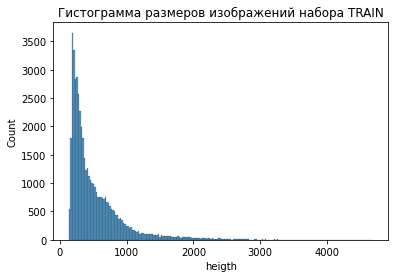

In [7]:
sns.histplot(df_train['heigth'])
plt.title('Гистограмма размеров изображений набора TRAIN')

print("Базовые метрики размеров изображений набора TRAIN:")
print(df_train['heigth'].describe())
print("------------------------------------")

print("Самые популярные значения метрики, топ 5")
print(df_train['heigth'].value_counts().nlargest(5))
print("------------------------------------")
print('\nВсе изображения имеют квадратную форму, кроме',df_train[df_train['notsquare'] != 0]['notsquare'].count(),'шт:')
df_train[df_train['notsquare'] != 0].sort_values('notsquare', ascending = False).head()

###### Оценим визуально несколько изображений с 'aspect ratio' не равным 1

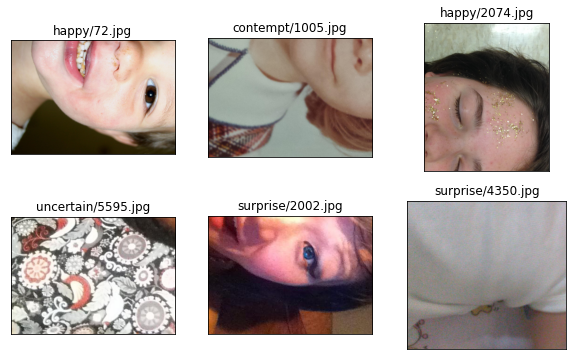

In [ ]:
image_list = df_train[df_train['notsquare'] != 0].sort_values('notsquare', ascending = False)['filename'].tolist()
emotion_list = df_train[df_train['notsquare'] != 0].sort_values('notsquare', ascending = False)['emotion'].tolist()
plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.title(emotion_list[i] + str('/') + image_list[i])
    plt.grid(False)
    image_path = str(PATH_TRAIN) + str('/') + str(emotion_list[i]) + str('/') + str(image_list[i])
    img = mpimg.imread(image_path)
    plt.imshow(img, cmap=plt.cm.gray)

### Графическое представление количественных характеристик TRAIN-датасета

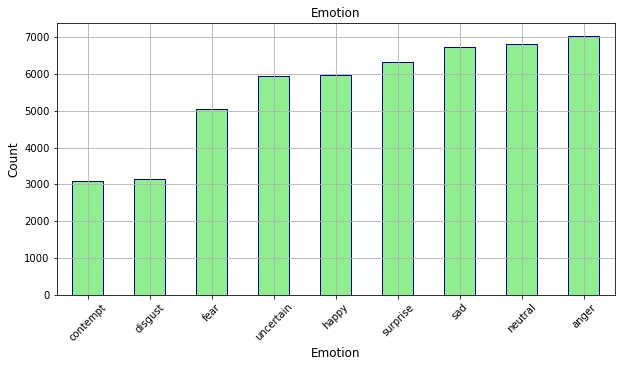

In [ ]:
df_train = pd.read_csv(BASE_DIR/'df_train.csv', sep=',', index_col='index')
df_train_group = df_train.groupby('emotion').agg({'filename': 'count'}).sort_values('filename', ascending = True)
df_train_group['emotion'] = df_train_group.index
ax = df_train_group[['emotion','filename']].plot(kind='bar', title ="Emotion", 
                                                      figsize=(10, 5), legend=False, rot = 45, 
                                                      fontsize = 10, color = 'lightgreen', 
                                                      edgecolor = 'darkblue',linewidth = 1)
ax.set_xlabel("Emotion", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid()
plt.show()

# Размеры представленных изображений ТЕСТового набора и статистика по ним

In [ ]:
folder_images = PATH_TEST
size_images = dict()

for dirpath, _, filenames in os.walk(folder_images):
    for path_image in filenames:
        image = os.path.abspath(os.path.join(dirpath, path_image))
        with Image.open(image) as img:
            weight = os.path.getsize(image)
            width, heigth = img.size
            size_images[path_image] = {'weight': weight, 'width': width, 'heigth': heigth}

df_test = pd.DataFrame(size_images).T
df_test['notsquare'] = abs(df_test['heigth'] - df_test['width'])
df_test['image_path'] = df_test.index
#сохраним полученный датафрейм в csv-файл
df_test.to_csv(BASE_DIR/'df_test.csv', sep=',', index_label='index')

Базовые метрики изображений ТЕСТового набора:
count    5000.000000
mean      523.301600
std       413.952547
min       135.000000
25%       248.000000
50%       379.000000
75%       668.000000
max      3709.000000
Name: heigth, dtype: float64
------------------------------------
Самые популярные значения метрики, топ 5
256    34
194    32
183    32
203    31
231    31
Name: heigth, dtype: int64
------------------------------------

Все изображения имеют квадратную форму, кроме 2 - х:
1008.jpg, 4118.jpg



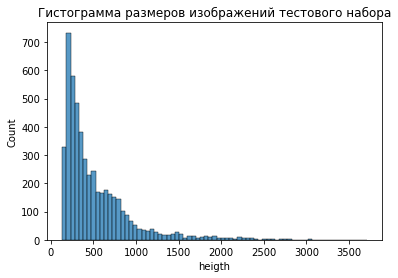

In [9]:
sns.histplot(df_test['heigth'])
plt.title('Гистограмма размеров изображений тестового набора')

print("Базовые метрики изображений ТЕСТового набора:")
print(df_test['heigth'].describe())
print("------------------------------------")

print("Самые популярные значения метрики, топ 5")
print(df_test['heigth'].value_counts().nlargest(5))
print("------------------------------------")
print('\nВсе изображения имеют квадратную форму, кроме',df_test[df_test['notsquare'] != 0]['notsquare'].count(),'- х:')
print(*df_test[df_test['notsquare'] != 0].index.tolist(),sep=', ',end='\n\n')

## Проведем исследование TRAIN-датасета на предмет яркости изображений и выведем наиболее затемненные/светлые фотографии


За пределы 3-х сигм выходит: 58 значений освещенности.

Базовые метрики освещенности
count    50046.000000
mean       115.840212
std         33.053753
min         10.939264
25%         94.006675
50%        115.349782
75%        137.658813
max        233.778174
Name: lvalueld, dtype: float64
------------------------------------
Самые популярные значения метрики освещенности, топ 5
161.590443    10
164.479591     9
130.398475     9
171.794429     7
98.782692      7
Name: lvalueld, dtype: int64
------------------------------------
Эксцесс  -0.04870398096108275
Ассиметрия  0.048621714574904044 



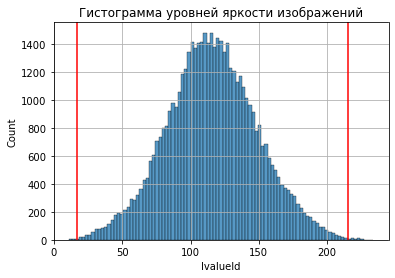

In [ ]:
lvalueld_list = []
for idx, row in df_train.iterrows():
    image_path = str(PATH_TRAIN) + str('/') + row[3] + str('/') + row[4]
    image = cv2.imread(image_path)
    hsld  = cv2.cvtColor(image, cv2.COLOR_BGR2HLS)
    Lchanneld = hsld[:,:,1]
    lvalueld =cv2.mean(Lchanneld)[0]
    lvalueld_list.append(lvalueld)
df_train = df_train.assign(lvalueld = lvalueld_list).sort_values('lvalueld', ascending = True)

upper_level = df_train.lvalueld.mean() + 3*df_train.lvalueld.std()
lower_level = df_train.lvalueld.mean() - 3*df_train.lvalueld.std()
sns.histplot(df_train.lvalueld)
plt.axvline(x=lower_level, color="r", linestyle="-")
plt.axvline(x=upper_level, color="r", linestyle="-")
plt.title('Гистограмма уровней яркости изображений')
plt.grid()
print('\nЗа пределы 3-х сигм выходит:',
      df_train[(df_train['lvalueld'] < lower_level) | (df_train['lvalueld'] > upper_level)]['lvalueld'].count(), 'значений освещенности.\n')
print("Базовые метрики освещенности")
print(df_train.lvalueld.describe())
print("------------------------------------")

print("Самые популярные значения метрики освещенности, топ 5")
print(df_train.lvalueld.value_counts().nlargest(5))
print("------------------------------------")

print("Эксцесс ", kurtosis(df_train.lvalueld))
print("Ассиметрия ", skew(df_train.lvalueld),'\n')

#сохраним полученный датафрейм в csv-файл
df_train.to_csv(BASE_DIR/'df_train.csv', sep=',', index_label='index')

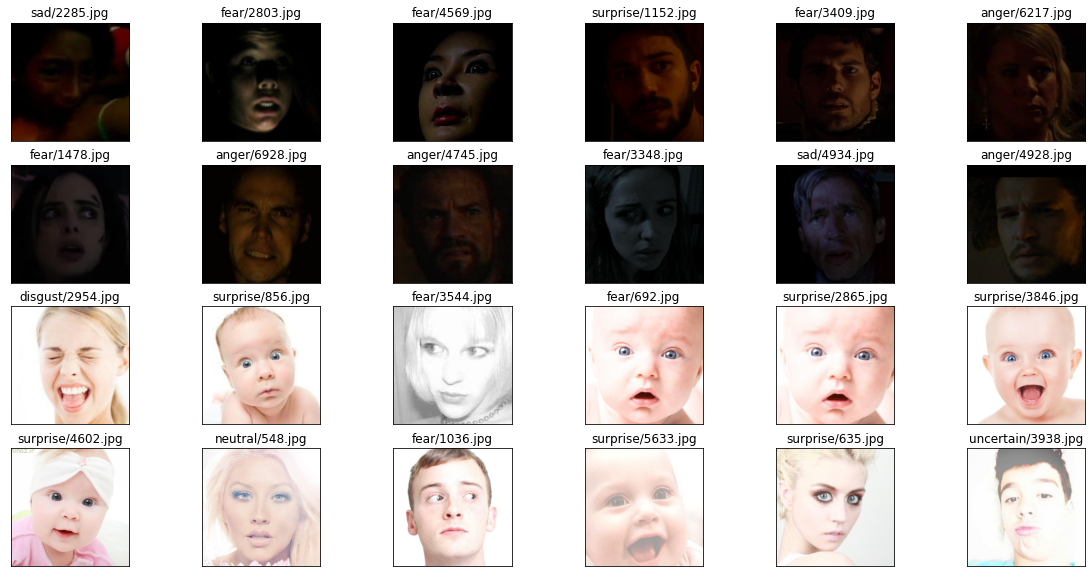

In [ ]:
# визуально оценим различия самой темной группы изображений от самой светлой
dark_light = [i for i in range(0,12)]
dark_light.extend([i for i in range(df_train.shape[0] - 12, df_train.shape[0])])
j = 0
plt.figure(figsize=(20,10))

for i in dark_light:
    plt.subplot(4,6, j+1)
    image_path = str(PATH_TRAIN) + str('/') + df_train.iloc[i][3] + str('/') + df_train.iloc[i][4]
    plt.title(df_train.iloc[i][3] + str('/') + df_train.iloc[i][4])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    img = mpimg.imread(image_path)
    plt.imshow(img, cmap=plt.cm.gray)
    j += 1

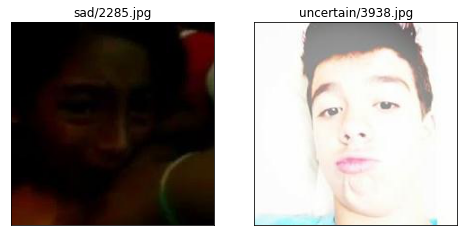

In [ ]:
# Граничные (min/max) варианты яркости изображений
dark_light = [i for i in range(0,12)]
dark_light.extend([i for i in range(df_train.shape[0] - 12, df_train.shape[0])])
plt.figure(figsize=(8,8))
j = 0
for i in [dark_light[0],dark_light[-1]]:
    plt.subplot(1,2, j+1)
    image_path = str(PATH_TRAIN) + str('/') + df_train.iloc[i][3] + str('/') + df_train.iloc[i][4]
    plt.title(df_train.iloc[i][3] + str('/') + df_train.iloc[i][4])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    img = mpimg.imread(image_path)
    plt.imshow(img, cmap=plt.cm.gray)
    j += 1



1. В датасете присутствуют одинаковые изображения, НО! относящиеся к разным эмоциям. Необходимо удалить данные изображения из тренировочного датасета с целью увеличения точности будущей модели распознавания эмоций.
2. В датасете присуствуют очень темные/светлые изображения, которые целесообразно привести к более усредненным уровням яркости/контраста.
3. В TRAIN-датасете присутствуют изображения, НЕ содержащие лиц, с фрагментами лиц, с несколькими лицами, изображения, по которым распознать эмоции не представляется возможным. В связи с этим, нам необходимо удалить данные изображения из тренировочного датасета с целью увеличения точности будущей модели распознавания эмоций.
4. Всего TRAIN-датасет содержит 50046 файлов, все загружаются в формате RGB, хотя некоторые фото черно-белые.
5. Половина изображений имеет размер в пределах 247-660px, минимальный размер 133px, максимальный - 4689px.
6. Категории распределены не равномерно: заметный недостаток лиц в категориях contempt и disgust.
7. Большинство изображений близки к равным пропорциям ширины и высоты, с некоторыми исключениями. Заодно видим, что некоторые фотографии даже не являются лицами, либо само лицо сильно обрезано, а некоторые изображения могут быть развернуты на 90 градусов.

# Предподготовка TRAIN-датасета на основе проведенного EDA

## 1) Удаление идентичных изображений по вычисленным хеш-функциям

In [ ]:
df_train = pd.read_csv(BASE_DIR/'df_train.csv', sep=',', index_col='index')

In [ ]:
df_clean = df_train[~df_train.duplicated(subset = ['hash'], keep = 'first')].copy()
df_clean = df_clean.groupby('hash').agg({'emotion': 'nunique', 'filename' : 'nunique'})
assert sum(set(df_clean.emotion.tolist())) == 1
assert sum(set(df_clean.filename.tolist())) == 1
print('Дубликаты изображений удалены успешно. Удалено', 50046 - df_clean.shape[0],'записей о файлах.\n')
df_train = df_train.loc[~df_train.duplicated(subset = ['hash'], keep = 'first')]
df_train.reset_index(drop=True, inplace=True)
df_train.drop(['hash'], axis=1, inplace=True)
df_train

Дубликаты изображений удалены успешно. Удалено 736 записей о файлах.



,weight,width,heigth,emotion,filename,notsquare,lvalueld
0,3059,209,209,sad,2285.jpg,0,10.939264
1,7878,379,379,fear,2803.jpg,0,11.865651
2,3039,192,192,fear,4569.jpg,0,12.455973
3,15959,675,675,surprise,1152.jpg,0,12.743730
4,15547,616,616,fear,3409.jpg,0,13.185115
...,...,...,...,...,...,...,...
49305,175140,1514,1514,neutral,548.jpg,0,225.409093
49306,71626,951,951,fear,1036.jpg,0,226.492290
49307,11845,466,466,surprise,5633.jpg,0,230.773186
49308,8148,334,334,surprise,635.jpg,0,231.220822


## 2) Нормализация уровня яркости/контраста

In [ ]:
# row[4] - emotion, row[5] - filename
for row in df_train.itertuples():
    image_path = str(PATH_TRAIN) + str('/') + row[4] + str('/') + row[5]
    img = Image.open(image_path)
    img = ImageOps.autocontrast(img, cutoff = 2, ignore = 2)
    img.save(image_path)

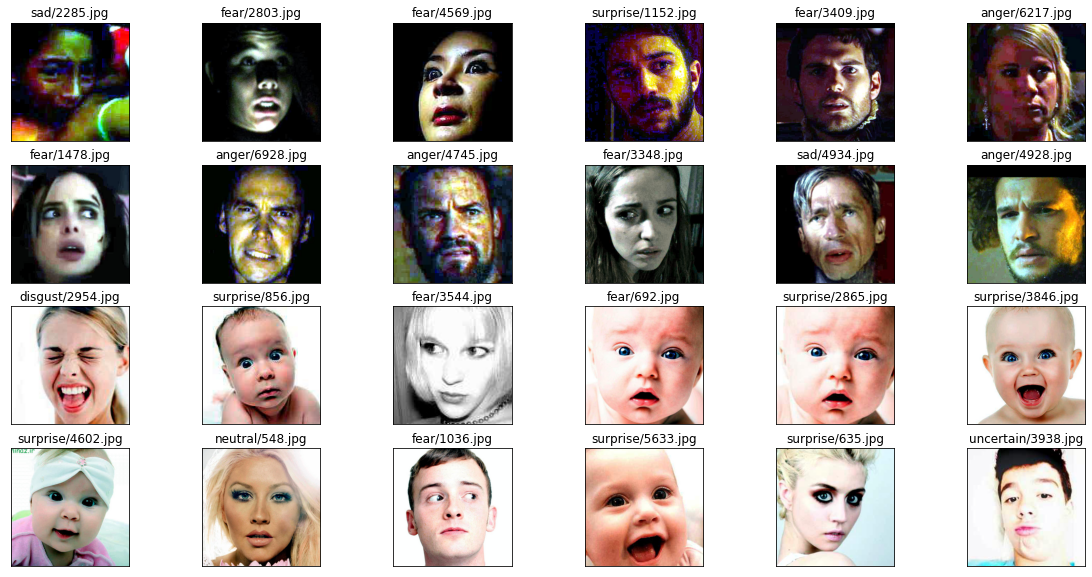

In [ ]:
# оценим полученные результаты нормализации по яркости/контрасту
dark_light = [i for i in range(0,12)]
dark_light.extend([i for i in range(df_train.shape[0] - 12, df_train.shape[0])])
j = 0
plt.figure(figsize=(20,10))

for i in dark_light:
    plt.subplot(4,6, j+1)
    image_path = str(PATH_TRAIN) + str('/') + df_train.iloc[i][3] + str('/') + df_train.iloc[i][4]
    plt.title(df_train.iloc[i][3] + str('/') + df_train.iloc[i][4])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    img = mpimg.imread(image_path)
    plt.imshow(img, cmap=plt.cm.gray)
    j += 1

## 3) Удаление изображений без лиц, фрагментированных изображений и изображений со множеством лиц:

- ### Этап 1. Multi-task Cascaded Convolutional Networks (MTCNN).

Наиболее длительный, но в то же время, наиболее качественный алгоритм детектирования лица на фото по обязательным 7 точкам (углы глаз, углы губ, кончик носа) и необрезанному овалу лица.

Определим необходимые функции

In [ ]:
def get_boxes(image):
    
    """Функция для CV-DNN. Запускает инференс детектора. Принимает на вход массив 
    и возвращает список с координатами bounding box """
    
    height, width = image.shape[:2]
    conf_threshold = 0.5
    
    blob = cv2.dnn.blobFromImage(
        image=image, 
        scalefactor=1.0,
        size=(300, 300), 
        mean=(104.0, 177.0, 123.0),
        swapRB=True,
    )
    
    detector.setInput(blob)
    detections = detector.forward()
    
    boxes = []
    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * width)
            y1 = int(detections[0, 0, i, 4] * height)
            x2 = int(detections[0, 0, i, 5] * width)
            y2 = int(detections[0, 0, i, 6] * height)
            boxes.append((x1, y1, x2, y2))
    return boxes


def draw_boxes(image, boxes):
    
    """Рисует bounding boxes на изображениях.
    Принимает на вход массив и возвращает изображение"""
    img = Image.fromarray(image)
    image_draw = ImageDraw.Draw(img)
    for box in boxes:
        x1, y1, x2, y2 = box
        image_draw.rectangle([x1, y1, x2, y2], fill=None, outline=(0,255,0), width=7)   
    return img


def draw_boxes_with_labels(image, boxes, predict):
    
    """Рисует bounding boxes на изображениях.
    Принимает на вход массив и возвращает изображение"""
    for box in boxes:
        x1, y1, x2, y2 = box
        bb.add(image, x1, y1, x2, y2, predict, 'green')
    img = Image.fromarray(image)
    image_draw = ImageDraw.Draw(img)  
    return img


def show_image(data, limit=100, show_labels=True, show_boxes=False, show_path=False, show_boxes_with_labels=False):
    
    """
    Отображает изображения с возможностью отрисовки bounding box 
    и меток, но не более чем указано в лимите.
    Принимает на вход срез датафрейма с указанными путями к файлам
    """
    
    if data.shape[0] > limit:
        data = data.head(limit)
        
    grid_dim = np.ceil(np.sqrt(data.shape[0])).astype('int')
    plt.figure(figsize=(15, 15))
    data_folder = PATH_TRAIN
    for i, file in enumerate(data['image_path']):
        with Image.open(data_folder / file) as image:
            plt.subplot(grid_dim, grid_dim, i+1)
            if show_boxes:
                img_np = np.array(image)
                boxes = get_boxes(img_np)
                plt.imshow(draw_boxes(img_np, boxes))
            elif show_boxes_with_labels:
                img_np = np.array(image)
                boxes = get_boxes(img_np)
                predict = data['emotion'].iloc[i]
                plt.imshow(draw_boxes_with_labels(img_np, boxes, predict))             
            else:
                plt.imshow(image)
            if show_labels:
                plt.title(data['emotion'].iloc[i])
            if show_path:
                plt.title(data['image_path'].iloc[i])               
            plt.xticks([])
            plt.yticks([])
    plt.show()

In [ ]:
from mtcnn.mtcnn import MTCNN
tf.get_logger().setLevel('ERROR')

detector = MTCNN()
noface_list = []
path_row = []

for row in df_train.itertuples():
    image_path = str(PATH_TRAIN) + str('/') + row[4] + str('/') + row[5]
    image = plt.imread(image_path)
    faces = detector.detect_faces(image)
    if len(faces) == 0:
        noface_list.append(image_path[104:]) # срез полного пути до 'директории/файла'

# Промежуточный датафрейм со списком изображений без лиц
df_train_noface = pd.DataFrame()
foldername = []
filename = []
for row in noface_list:
    foldername.append(row.split('/')[0])
    filename.append(row.split('/')[1])   
column_values = pd.Series(foldername)
df_train_noface.insert(loc=0, column='foldername', value=column_values)
column_values = pd.Series(filename)
df_train_noface.insert(loc=1, column='filename', value=column_values)

# удаление записей с изображениями без лиц из основного датасета
for row in df_train_noface.itertuples():
    path_row.append(str(row[1]) + str('/') + str(row[2]))
    df_train.drop(df_train[(df_train['emotion'] == row[1]) 
                           & (df_train['filename'] == row[2])].index[0], inplace=True)
column_values = pd.Series(path_row)
df_train_noface.insert(loc=2, column='image_path', value=column_values)
df_train_noface['emotion'] = df_train_noface['foldername']
df_train.reset_index(drop=True, inplace=True)

# сохранение датасетов
df_train_noface.to_csv(BASE_DIR/'df_train_noface.csv', sep=',', index_label='index')
df_train.to_csv(BASE_DIR/'df_train.csv', sep=',', index_label='index')

print('MTCNN удалено', df_train_noface.shape[0],'записей о файлах, не распознанных как лица\n')

MTCNN удалено 286 записей о файлах, не распознанных как лица



In [ ]:
# считывание датасетов
df_train = pd.read_csv(BASE_DIR/'df_train.csv', sep=',', index_col='index')
df_train_noface = pd.read_csv(BASE_DIR/'df_train_noface.csv', sep=',', index_col='index')

Посмотрим на изображения, на которых детектор MTCNN не обнаружил лиц

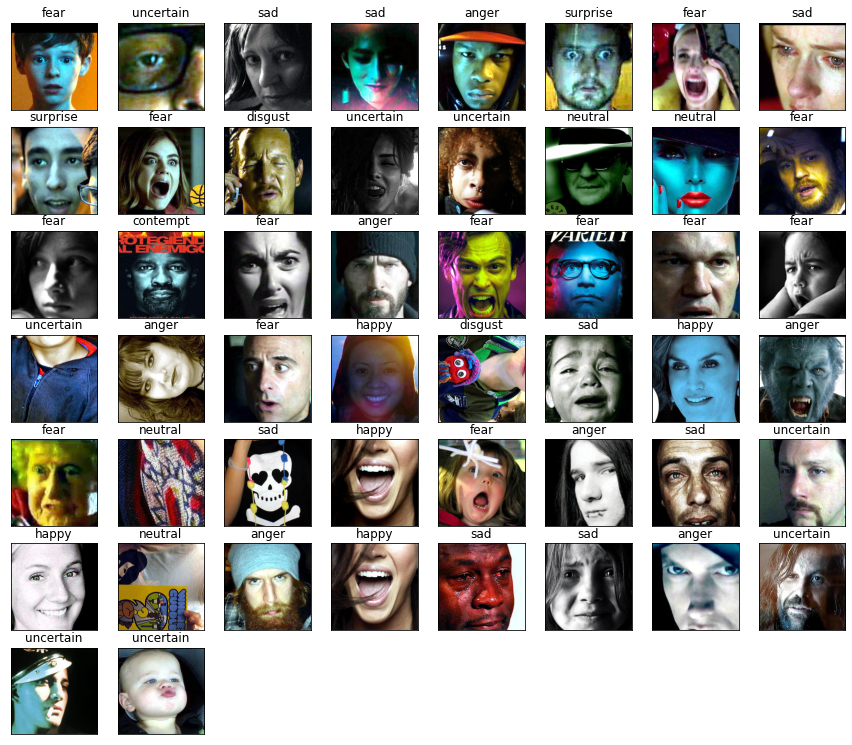

In [ ]:
show_image(df_train_noface, limit=50, show_boxes=False, show_labels=True)

- ### Этап 2. DNN Face Detector in OpenCV

In [ ]:
modelFile = str(BASE_DIR) + str('/res10_300x300_ssd_iter_140000.caffemodel')
configFile = str(BASE_DIR) + str('/deploy.prototxt')
detector = cv2.dnn.readNetFromCaffe(configFile, modelFile)

In [ ]:
face_count = []
path_row =[]

for row in df_train.itertuples():
    image_path = str(PATH_TRAIN) + str('/') + row[4] + str('/') + row[5]
    path_row.append(image_path[104:])
    with Image.open(image_path) as image:
        img_np = np.array(image)
        boxes = get_boxes(img_np)
        face_count.append(len(boxes))

column_values = pd.Series(path_row)
df_train.insert(loc=8, column='image_path', value=column_values)    
df_train['face_count'] = face_count
df_train.to_csv(BASE_DIR/'df_train.csv', sep=',', index_label='index')

Всего обнаружено 11 изображений


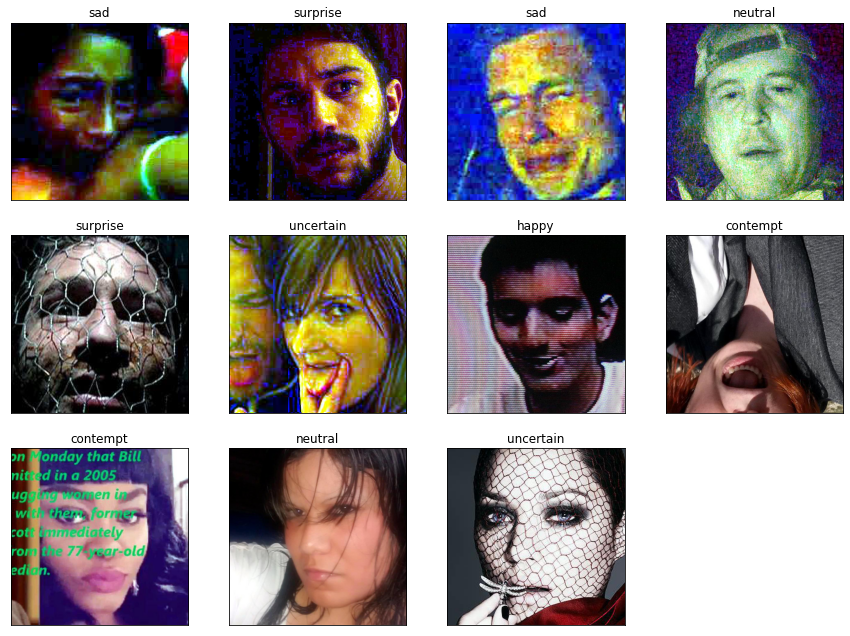

In [ ]:
print(f"Всего обнаружено {sum(df_train['face_count'] == 0)} изображений")
without_faces = df_train[df_train['face_count'] == 0]
show_image(without_faces, limit=60, show_boxes=True, show_labels=True)

In [ ]:
# удаляем 11 изображений
df_train = df_train[df_train['face_count'] != 0]
df_train.to_csv(BASE_DIR/'df_train.csv', sep=',', index_label='index')

И на изображения, на которых лиц больше чем одно

In [ ]:
df_train = pd.read_csv(BASE_DIR/'df_train.csv', sep=',', index_col='index')

Всего обнаружено 527 изображений


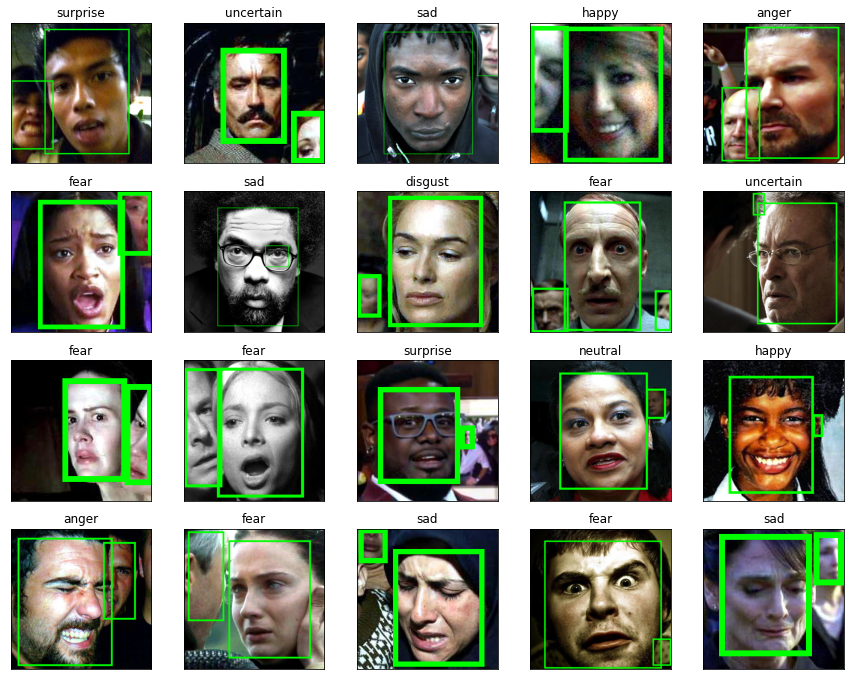

In [ ]:
print(f"Всего обнаружено {sum(df_train['face_count'] > 1)} изображений")
more_the_one_face = df_train[df_train['face_count'] > 1]
show_image(more_the_one_face, limit=20, show_boxes=True, show_labels=True)

Подготовим альтернативный набор изображений, в котором каждое изображение обрезано по bounding_box-у для проведения сравнительных тестов.
#### Из фотографий со множеством лиц вырежем bounding box c наибольшей площадью. 
#### Из фотографий с одним лицом также возьмем только область bounding box-а.

In [ ]:
# row[9] - image_path (emotion/filename.jpg)
# row[4] - emotion, row[5] - filename

save_dir = BASE_DIR / 'processed'
save_dir.mkdir(exist_ok=True)

max_box_indices = []

for row in df_train.itertuples():
    image_path = str(PATH_TRAIN) + str('/') + row[9]
    with Image.open(image_path) as image:
        img = np.array(image.convert('RGB'))
        img_np = np.array(image)
        boxes = get_boxes(img_np)
        # find box index with the largest area
        max_area = 0
        max_box_idx = 0
        for i, box in enumerate(boxes):
            startW, startH, endW, endH = box
            if np.abs((endW - startW) * (endH - startH)) > max_area:
                max_area = np.abs((endW - startW) * (endH - startH))
                max_box_idx = i
        max_box_indices.append(max_box_idx)
        startW, startH, endW, endH = boxes[max_box_idx]
        face = img[startH:endH, startW:endW]
        
        cat_dir = save_dir / Path(row[4])
        cat_dir.mkdir(exist_ok=True)
        file_name = cat_dir / Path(row[5])
        Image.fromarray(face).save(file_name)
len(max_box_indices), sum(max_box_indices), np.max(max_box_indices)

(49013, 17, 1)

Описательные характеристики полученного датасета с обрезанными bounding_box-ами

Базовые метрики размеров изображений набора PROCESSED:
count    49013.000000
mean       464.712097
std        376.554820
min         87.000000
25%        220.000000
50%        334.000000
75%        583.000000
max       4639.000000
Name: heigth, dtype: float64
------------------------------------
Самые популярные значения метрики, топ 5
187    194
210    180
190    173
182    161
194    160
Name: heigth, dtype: int64
------------------------------------

Все изображения имеют квадратную форму, кроме 27 шт:


,weight,width,heigth,emotion,filename,notsquare
2720,7158,150,202,happy,3683.jpg,50.0
6252,12180,238,341,uncertain,2129.jpg,50.0
9040,5660,159,240,uncertain,3856.jpg,50.0
8845,34451,432,543,uncertain,3274.jpg,50.0
8578,8214,192,231,uncertain,4113.jpg,50.0


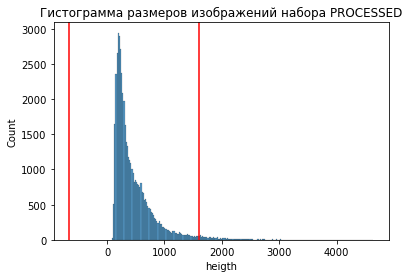

In [ ]:
idx = 0
size_images = dict()

folders = ([name for name in os.listdir(PATH_PROCESSED)
            if os.path.isdir(os.path.join(PATH_PROCESSED, name))])
for folder in folders:
    folder_images = PATH_PROCESSED/folder
    for dirpath, _, filenames in os.walk(folder_images):
        for path_image in filenames:
            image = os.path.abspath(os.path.join(dirpath, path_image))
            weight = os.path.getsize(image)
            with Image.open(image) as img:
                width, heigth = img.size
                size_images[idx] = {'weight': weight, 
                                'width': width, 
                                'heigth': heigth, 
                                'emotion' : folder, 
                                'filename': path_image}
            idx += 1

df_processed = pd.DataFrame(size_images).T
df_processed = df_processed.astype({'width': int, 'heigth': int})

path_row = []
for row in df_processed.itertuples():
    image_path = row[4] + str('/') + row[5]
    path_row.append(image_path)
    
column_values = pd.Series(path_row)
df_processed.insert(loc=6, column='image_path', value=column_values)

upper_level = df_processed['heigth'].mean()\
    + 3*df_processed['heigth'].std()
lower_level = df_processed['heigth'].mean()\
    - 3*df_processed['heigth'].std()
sns.histplot(df_processed['heigth'])
plt.axvline(x=lower_level, color="r", linestyle="-")
plt.axvline(x=upper_level, color="r", linestyle="-")
plt.title('Гистограмма размеров изображений набора PROCESSED')

print("Базовые метрики размеров изображений набора PROCESSED:")
print(df_processed['heigth'].describe())
print("------------------------------------")

print("Самые популярные значения метрики, топ 5")
print(df_processed['heigth'].value_counts().nlargest(5))
print("------------------------------------")

df_processed['notsquare'] = abs(df_train['heigth'] - df_train['width'])

#сохраним полученный датафрейм в csv-файл
df_processed.to_csv(BASE_DIR/'df_processed.csv', sep=',', index_label='index')

print('\nВсе изображения имеют квадратную форму, кроме',df_processed[df_processed['notsquare'] != 0]['notsquare'].count(),'шт:')
df_processed[df_processed['notsquare'] != 0].sort_values('notsquare', ascending = False).head()

Мы получили ДВА набора изображений, пригодных для дальнейшего обучения ML-модели. Подобный подход позволит опеределить нам более подходящий способ подготовки исходных данных в сравнении.
1. Датасет №1. Ключевые признаки.
    - удалены изображения, не распознанные алгоритмом MTCNN как лицо человека
    - удалены изображения, не распознанные алгоритмом CV-DNN как лицо человека
    - удалены изображения с идентичной хеш-функцией
    - нормализован уровень яркости/контраста
    - изображения НЕ обрезаны по bounding_box-y (рамке лица)
    - ПРИСУТСТВУЮТ изображения с двумя и более лицами

1. Датасет №2. Ключевые признаки.
    - удалены изображения, не распознанные алгоритмом MTCNN как лицо человека
    - удалены изображения, не распознанные алгоритмом CV-DNN как лицо человека
    - удалены изображения с идентичной хеш-функцией
    - нормализован уровень яркости/контраста
    - ВСЕ изображения (в том числе одиночные) ОБРЕЗАНЫ по наибольшему bounding_box-y (рамке лица)
    - ОТСУТСТВУЮТ изображения с двумя и более лицами (следствие предыдущего пункта)